In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

print("Python environment is working!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Python environment is working!
Pandas version: 3.0.5
NumPy version: 2.5.2


In [2]:
PROCESSED_PATH = "../data/processed"

csv_files = [
    f for f in os.listdir(PROCESSED_PATH)
    if f.lower().endswith(".csv")
]

for f in csv_files:
    print(f)

commodity_prices_processed.csv
freight_rates.csv
india_bulk_imports_2022_2026.csv
oil_geopolitics_processed.csv
port_congestion_processed.csv
trade_flows_processed.csv
vessel_performance_processed.csv


In [3]:


vessel = pd.read_csv(
    os.path.join(PROCESSED_PATH, "vessel_performance_processed.csv")
)

trade = pd.read_csv(
    os.path.join(PROCESSED_PATH, "trade_flows_processed.csv")
)

congestion = pd.read_csv(
    os.path.join(PROCESSED_PATH, "port_congestion_processed.csv")
)

oil = pd.read_csv(
    os.path.join(PROCESSED_PATH, "oil_geopolitics_processed.csv")
)

india_imports = pd.read_csv(
    os.path.join(PROCESSED_PATH, "india_bulk_imports_2022_2026.csv")
)

freight = pd.read_csv(
    os.path.join(PROCESSED_PATH, "freight_rates.csv")
)

commodity = pd.read_csv(
    os.path.join(PROCESSED_PATH, "commodity_prices_processed.csv")

)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
datasets = {
    "Vessel Performance": vessel,
    "Trade Flows": trade,
    "Port Congestion": congestion,
    "Oil Geopolitics": oil,
    "India Bulk Imports": india_imports,
    "Freight Rates": freight,
    "Commodity Prices": commodity
}

inventory = []

for name, data in datasets.items():
    inventory.append({
        "Dataset": name,
        "Rows": data.shape[0],
        "Columns": data.shape[1],
        "Duplicate Rows": data.duplicated().sum(),
        "Missing Cells": data.isna().sum().sum()
    })

inventory_df = pd.DataFrame(inventory)

display(inventory_df)

,Dataset,Rows,Columns,Duplicate Rows,Missing Cells
0,Vessel Performance,2736,20,0,680
1,Trade Flows,1250,13,0,50
2,Port Congestion,6260,12,0,0
3,Oil Geopolitics,4047,25,0,0
4,India Bulk Imports,11200,10,0,0
5,Freight Rates,300,10,0,13
6,Commodity Prices,1176,8,0,0


In [5]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(data.columns.tolist())


Vessel Performance
['date', 'year', 'month', 'ship_type', 'route_type', 'engine_type', 'maintenance_status', 'speed_over_ground_knots', 'engine_power_kw', 'distance_traveled_nm', 'draft_meters', 'weather_condition', 'cargo_weight_tons', 'operational_cost_usd', 'revenue_per_voyage_usd', 'turnaround_time_hours', 'efficiency_nm_per_kwh', 'seasonal_impact_score', 'weekly_voyage_count', 'average_load_percentage']

Trade Flows
['year', 'exporter', 'importer', 'trade_category', 'key_goods', 'trade_value_bn_usd', 'yoy_growth_pct', 'effective_tariff_rate_pct', 'trade_active', 'supply_chain_integrated', 'concentration_risk', 'india_import_flow', 'india_export_flow']

Port Congestion
['week_start', 'year', 'month', 'port', 'country', 'region', 'throughput_teu_mn', 'vessels_at_anchor', 'avg_wait_days', 'congestion_index', 'port_utilization_pct', 'berth_delay_hrs']

Oil Geopolitics
['date', 'year', 'month', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 

In [6]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    display(data.head())


Vessel Performance


,date,year,month,ship_type,route_type,engine_type,maintenance_status,speed_over_ground_knots,engine_power_kw,distance_traveled_nm,draft_meters,weather_condition,cargo_weight_tons,operational_cost_usd,revenue_per_voyage_usd,turnaround_time_hours,efficiency_nm_per_kwh,seasonal_impact_score,weekly_voyage_count,average_load_percentage
0,2023-06-04,2023,6,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,2023,6,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,2023,6,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,2023,6,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,2023,7,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581



Trade Flows


,year,exporter,importer,trade_category,key_goods,trade_value_bn_usd,yoy_growth_pct,effective_tariff_rate_pct,trade_active,supply_chain_integrated,concentration_risk,india_import_flow,india_export_flow
0,2000,Australia,China,commodities,"iron ore,coal,LNG",23.18,NaN,2.5,1,0,0.158,0,0
1,2001,Australia,China,commodities,"iron ore,coal,LNG",26.71,15.23,2.5,1,0,0.404,0,0
2,2002,Australia,China,commodities,"iron ore,coal,LNG",26.44,-1.01,2.5,1,0,0.537,0,0
3,2003,Australia,China,commodities,"iron ore,coal,LNG",27.68,4.69,2.5,1,0,0.381,0,0
4,2004,Australia,China,commodities,"iron ore,coal,LNG",29.89,7.98,2.5,1,0,0.363,0,0



Port Congestion


...

,Year,Period_Start,Period_End,Commodity,Country_of_Consignment,Port,Unit,Quantity,Value_INR,Value_USD
0,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,CHENNAI SEA,TON,0,0,0
1,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,JAIGAD,TON,660922,2517138692,32492462
2,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,KANDLA SEA,TON,58569,630745266,8227111
3,2022,2022-01-01,2022-12-31,IRON ORE,BRAZIL,DELHI AIR,TON,0,0,0
4,2022,2022-01-01,2022-12-31,IRON ORE,BRAZIL,JAIGAD,TON,462950,3533164900,46278382



Freight Rates


,date,year,month,baltic_dry_index,bulk_carrier_handysize_usd_day,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct
0,2000-01-01,2000,1,1239,4195,32524,0.50,0.930,NaN,NaN
1,2000-02-01,2000,2,1210,15111,32035,0.70,0.946,-2.34,NaN
2,2000-03-01,2000,3,1286,15513,17328,0.69,0.923,6.28,NaN
3,2000-04-01,2000,4,1216,10591,21573,0.85,0.926,-5.44,NaN
4,2000-05-01,2000,5,1316,9951,21748,0.62,0.934,8.22,NaN



Commodity Prices


,date,year,month,commodity,category,unit,currency,average_price
0,2010-01-01,2010,1,Corn,soft,bushel,USD,3.759782
1,2010-01-01,2010,1,Palm Oil,soft,tonne,USD,750.371645
2,2010-01-01,2010,1,Soybeans,soft,bushel,USD,10.015400
3,2010-01-01,2010,1,Sugar,soft,lb,USD,0.285227
4,2010-01-01,2010,1,Thermal Coal Newcastle,energy,tonne,USD,94.715118


In [7]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    audit = pd.DataFrame({
        "Column": data.columns,
        "Data Type": data.dtypes.astype(str).values,
        "Missing Values": data.isna().sum().values,
        "Unique Values": data.nunique().values
    })

    display(audit)


Vessel Performance


,Column,Data Type,Missing Values,Unique Values
0,date,str,0,57
1,year,int64,0,2
2,month,int64,0,12
3,ship_type,str,136,4
4,route_type,str,136,4
5,engine_type,str,136,3
6,maintenance_status,str,136,3
7,speed_over_ground_knots,float64,0,2736
8,engine_power_kw,float64,0,2736
9,distance_traveled_nm,float64,0,2736



Trade Flows


,Column,Data Type,Missing Values,Unique Values
0,year,int64,0,25
1,exporter,str,0,38
2,importer,str,0,9
3,trade_category,str,0,18
4,key_goods,str,0,46
5,trade_value_bn_usd,float64,0,1184
6,yoy_growth_pct,float64,50,973
7,effective_tariff_rate_pct,float64,0,4
8,trade_active,int64,0,2
9,supply_chain_integrated,int64,0,2



Port Congestion


...

,Column,Data Type,Missing Values,Unique Values
0,Year,int64,0,5
1,Period_Start,str,0,5
2,Period_End,str,0,5
3,Commodity,str,0,6
4,Country_of_Consignment,str,0,159
5,Port,str,0,238
6,Unit,str,0,1
7,Quantity,int64,0,4951
8,Value_INR,int64,0,9387
9,Value_USD,int64,0,8892



Freight Rates


,Column,Data Type,Missing Values,Unique Values
0,date,str,0,300
1,year,int64,0,25
2,month,int64,0,12
3,baltic_dry_index,int64,0,283
4,bulk_carrier_handysize_usd_day,int64,0,290
5,tanker_rate_aframax_usd_day,int64,0,291
6,supply_chain_pressure_index,float64,0,124
7,on_time_delivery_pct,float64,0,113
8,bdi_mom_change_pct,float64,1,282
9,container_yoy_pct,float64,12,276



Commodity Prices


,Column,Data Type,Missing Values,Unique Values
0,date,str,0,196
1,year,int64,0,17
2,month,int64,0,12
3,commodity,str,0,6
4,category,str,0,2
5,unit,str,0,3
6,currency,str,0,1
7,average_price,float64,0,1175


In [8]:
print(freight.columns.tolist())

['date', 'year', 'month', 'baltic_dry_index', 'bulk_carrier_handysize_usd_day', 'tanker_rate_aframax_usd_day', 'supply_chain_pressure_index', 'on_time_delivery_pct', 'bdi_mom_change_pct', 'container_yoy_pct']


In [9]:
freight.head(10)

,date,year,month,baltic_dry_index,bulk_carrier_handysize_usd_day,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct
0,2000-01-01,2000,1,1239,4195,32524,0.50,0.930,NaN,NaN
1,2000-02-01,2000,2,1210,15111,32035,0.70,0.946,-2.34,NaN
2,2000-03-01,2000,3,1286,15513,17328,0.69,0.923,6.28,NaN
3,2000-04-01,2000,4,1216,10591,21573,0.85,0.926,-5.44,NaN
4,2000-05-01,2000,5,1316,9951,21748,0.62,0.934,8.22,NaN
5,2000-06-01,2000,6,1391,14602,18404,0.86,0.935,5.70,NaN
6,2000-07-01,2000,7,1265,15485,26749,0.77,0.936,-9.06,NaN
7,2000-08-01,2000,8,1339,10721,13342,0.65,0.909,5.85,NaN
8,2000-09-01,2000,9,1328,5268,32746,0.69,0.921,-0.82,NaN
9,2000-10-01,2000,10,1416,10150,22210,0.95,0.917,6.63,NaN


In [10]:
freight.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   date                            300 non-null    str    
 1   year                            300 non-null    int64  
 2   month                           300 non-null    int64  
 3   baltic_dry_index                300 non-null    int64  
 4   bulk_carrier_handysize_usd_day  300 non-null    int64  
 5   tanker_rate_aframax_usd_day     300 non-null    int64  
 6   supply_chain_pressure_index     300 non-null    float64
 7   on_time_delivery_pct            300 non-null    float64
 8   bdi_mom_change_pct              299 non-null    float64
 9   container_yoy_pct               288 non-null    float64
dtypes: float64(4), int64(5), str(1)
memory usage: 23.6 KB


In [11]:
display(freight.describe())

,year,month,baltic_dry_index,bulk_carrier_handysize_usd_day,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct
count,300.000000,300.00000,300.000000,300.000000,300.000000,300.00000,300.000000,299.000000,288.000000
mean,2012.000000,6.50000,2374.113333,11155.036667,26444.463333,1.09880,0.898237,2.445987,8.233646
std,7.223151,3.45782,1712.922795,4472.017218,10599.641654,0.47657,0.044803,41.356688,36.709979
min,2000.000000,1.00000,300.000000,3000.000000,8000.000000,0.50000,0.687000,-45.080000,-73.730000
25%,2006.000000,3.75000,1339.000000,7926.250000,20642.000000,0.81000,0.888750,-5.935000,-8.685000
50%,2012.000000,6.50000,1823.500000,11254.500000,25715.500000,0.99500,0.907000,0.000000,2.480000
75%,2018.000000,9.25000,2560.750000,13945.750000,30747.750000,1.23000,0.923000,6.515000,18.252500
max,2024.000000,12.00000,9930.000000,21829.000000,80000.000000,2.92000,0.980000,690.000000,193.540000


In [12]:
display(freight.isna().sum())

date                               0
year                               0
month                              0
baltic_dry_index                   0
bulk_carrier_handysize_usd_day     0
tanker_rate_aframax_usd_day        0
supply_chain_pressure_index        0
on_time_delivery_pct               0
bdi_mom_change_pct                 1
container_yoy_pct                 12
dtype: int64

In [14]:
freight["date"] = pd.to_datetime(
    freight["date"],
    errors="coerce"
)

In [15]:
print("Minimum date:", freight["date"].min())
print("Maximum date:", freight["date"].max())
print("Invalid dates:", freight["date"].isna().sum())

Minimum date: 2000-01-01 00:00:00
Maximum date: 2024-12-01 00:00:00
Invalid dates: 0


In [16]:
freight["date"].dt.to_period("M").nunique()

300

In [17]:
display(
    freight[
        ["date", "bulk_carrier_handysize_usd_day"]
    ].head(20)
)

,date,bulk_carrier_handysize_usd_day
0,2000-01-01,4195
1,2000-02-01,15111
2,2000-03-01,15513
3,2000-04-01,10591
4,2000-05-01,9951
5,2000-06-01,14602
6,2000-07-01,15485
7,2000-08-01,10721
8,2000-09-01,5268
9,2000-10-01,10150


In [18]:
target = "bulk_carrier_handysize_usd_day"

print("Target:", target)
print("Number of observations:", freight[target].notna().sum())
print("Missing target values:", freight[target].isna().sum())

Target: bulk_carrier_handysize_usd_day
Number of observations: 300
Missing target values: 0


In [19]:
display(freight[target].describe())

count      300.000000
mean     11155.036667
std       4472.017218
min       3000.000000
25%       7926.250000
50%      11254.500000
75%      13945.750000
max      21829.000000
Name: bulk_carrier_handysize_usd_day, dtype: float64

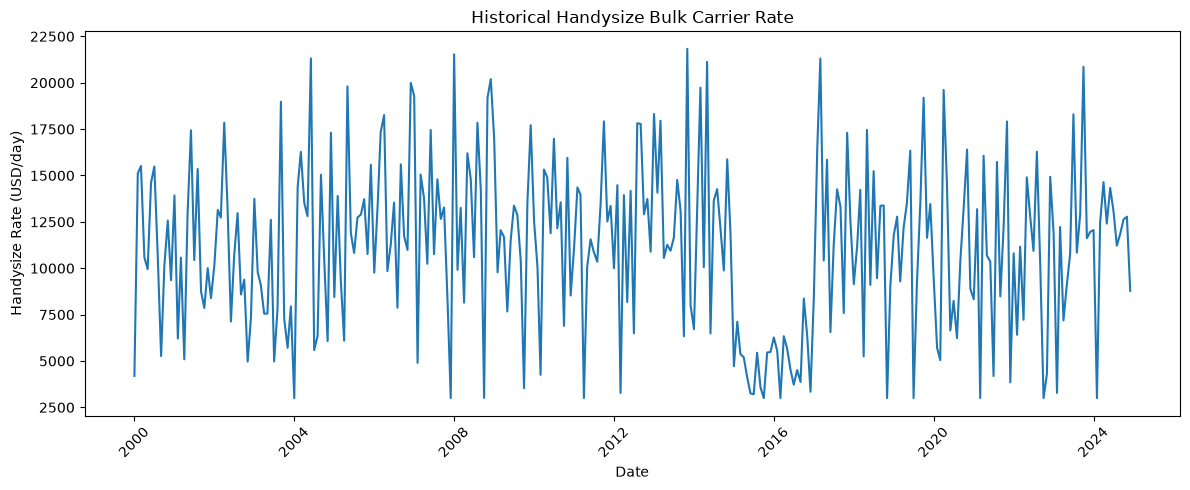

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    freight["date"],
    freight["bulk_carrier_handysize_usd_day"]
)

plt.xlabel("Date")
plt.ylabel("Handysize Rate (USD/day)")
plt.title("Historical Handysize Bulk Carrier Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
# freight data has one observation per month

monthly_counts = (
    freight
    .groupby(freight["date"].dt.to_period("M"))
    .size()
)

print("Number of unique months:", len(monthly_counts))
print("Minimum records in a month:", monthly_counts.min())
print("Maximum records in a month:", monthly_counts.max())

print("\nMonths with more than one record:")
display(monthly_counts[monthly_counts > 1])

print("\nMissing months:")
full_month_range = pd.period_range(
    start=freight["date"].min().to_period("M"),
    end=freight["date"].max().to_period("M"),
    freq="M"
)

missing_months = full_month_range.difference(monthly_counts.index)

display(missing_months)

Number of unique months: 300
Minimum records in a month: 1
Maximum records in a month: 1

Months with more than one record:


Series([], Freq: M, dtype: int64)


Missing months:


PeriodIndex([], dtype='period[M]')

In [22]:
target = "bulk_carrier_handysize_usd_day"

print("Target variable:", target)
print("Observations:", freight[target].count())
print("Missing values:", freight[target].isna().sum())

display(
    freight[target].describe()
)

Target variable: bulk_carrier_handysize_usd_day
Observations: 300
Missing values: 0


count      300.000000
mean     11155.036667
std       4472.017218
min       3000.000000
25%       7926.250000
50%      11254.500000
75%      13945.750000
max      21829.000000
Name: bulk_carrier_handysize_usd_day, dtype: float64

In [23]:
print("Minimum rate:",
      freight[target].min())

print("Maximum rate:",
      freight[target].max())

print("Mean rate:",
      freight[target].mean())

print("Median rate:",
      freight[target].median())

Minimum rate: 3000
Maximum rate: 21829
Mean rate: 11155.036666666667
Median rate: 11254.5


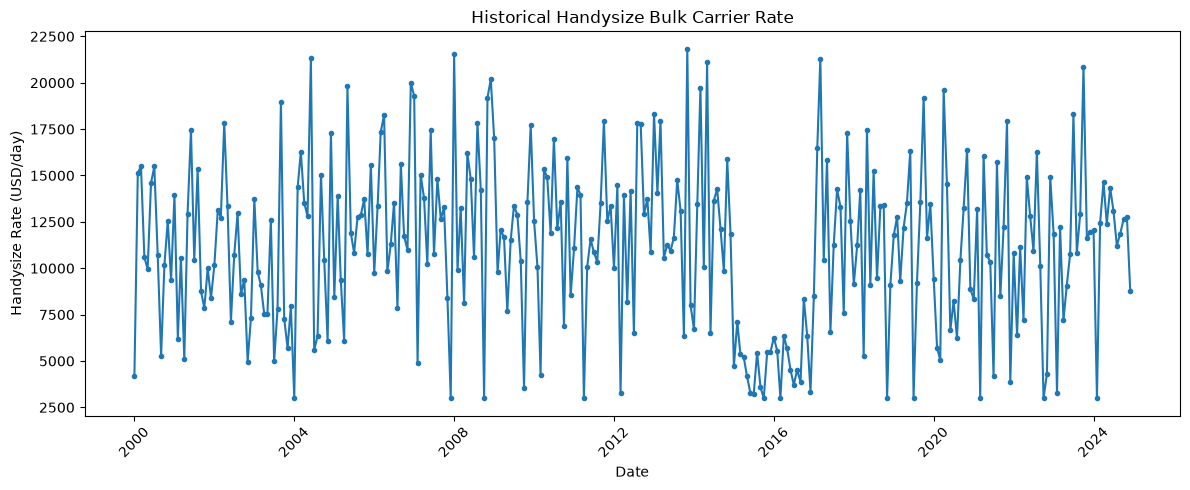

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    freight["date"],
    freight[target],
    marker="o",
    markersize=3
)

plt.xlabel("Date")
plt.ylabel("Handysize Rate (USD/day)")
plt.title("Historical Handysize Bulk Carrier Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
numeric_freight = freight.select_dtypes(
    include="number"
)

correlation = numeric_freight.corr()

display(
    correlation[target]
    .sort_values(ascending=False)
)

bulk_carrier_handysize_usd_day    1.000000
baltic_dry_index                  0.147664
bdi_mom_change_pct                0.109267
on_time_delivery_pct              0.063040
supply_chain_pressure_index       0.061041
month                             0.008583
container_yoy_pct                 0.002409
tanker_rate_aframax_usd_day      -0.052930
year                             -0.065996
Name: bulk_carrier_handysize_usd_day, dtype: float64

In [27]:
monthly_counts = (
    freight
    .groupby(freight["date"].dt.to_period("M"))
    .size()
)

In [28]:
display(freight[target].describe())

count      300.000000
mean     11155.036667
std       4472.017218
min       3000.000000
25%       7926.250000
50%      11254.500000
75%      13945.750000
max      21829.000000
Name: bulk_carrier_handysize_usd_day, dtype: float64

In [29]:
display(
    freight.select_dtypes(include="number")
    .corr()[target]
    .sort_values(ascending=False)
)

bulk_carrier_handysize_usd_day    1.000000
baltic_dry_index                  0.147664
bdi_mom_change_pct                0.109267
on_time_delivery_pct              0.063040
supply_chain_pressure_index       0.061041
month                             0.008583
container_yoy_pct                 0.002409
tanker_rate_aframax_usd_day      -0.052930
year                             -0.065996
Name: bulk_carrier_handysize_usd_day, dtype: float64

In [30]:
print("OIL DATASET")
print("=" * 60)

print("Shape:", oil.shape)

print("\nColumns:")
print(oil.columns.tolist())

print("\nFirst 5 rows:")
display(oil.head())

print("\nData types:")
oil.info()

OIL DATASET
Shape: (4047, 25)

Columns:
['date', 'year', 'month', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag']

First 5 rows:


,date,year,month,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,2010,2,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0.0,0
1,2010-02-18,2010,2,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0.0,0
2,2010-02-19,2010,2,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0.0,0
3,2010-02-22,2010,2,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0.0,0
4,2010-02-23,2010,2,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0.0,0



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 4047 entries, 0 to 4046
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4047 non-null   str    
 1   year                  4047 non-null   int64  
 2   month                 4047 non-null   int64  
 3   brent_price           4047 non-null   float64
 4   wti_price             4047 non-null   float64
 5   dxy_index             4047 non-null   float64
 6   vix                   4047 non-null   float64
 7   gpr_index             4047 non-null   float64
 8   brent_return          4047 non-null   float64
 9   wti_return            4047 non-null   float64
 10  brent_lag_1           4047 non-null   float64
 11  brent_lag_3           4047 non-null   float64
 12  brent_lag_7           4047 non-null   float64
 13  wti_lag_1             4047 non-null   float64
 14  wti_lag_3             4047 non-null   float64
 15  wti_lag_7          

In [31]:
print("Missing values:")
display(oil.isna().sum())

Missing values:


date                    0
year                    0
month                   0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

In [32]:
print("Duplicate rows:", oil.duplicated().sum())

Duplicate rows: 0


In [33]:
print(oil.columns.tolist())

['date', 'year', 'month', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag']


In [34]:
print("COMMODITY DATASET")
print("=" * 60)

print("Shape:", commodity.shape)

print("\nColumns:")
print(commodity.columns.tolist())

print("\nFirst 5 rows:")
display(commodity.head())

print("\nData types:")
commodity.info()

COMMODITY DATASET
Shape: (1176, 8)

Columns:
['date', 'year', 'month', 'commodity', 'category', 'unit', 'currency', 'average_price']

First 5 rows:


,date,year,month,commodity,category,unit,currency,average_price
0,2010-01-01,2010,1,Corn,soft,bushel,USD,3.759782
1,2010-01-01,2010,1,Palm Oil,soft,tonne,USD,750.371645
2,2010-01-01,2010,1,Soybeans,soft,bushel,USD,10.015400
3,2010-01-01,2010,1,Sugar,soft,lb,USD,0.285227
4,2010-01-01,2010,1,Thermal Coal Newcastle,energy,tonne,USD,94.715118



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1176 non-null   str    
 1   year           1176 non-null   int64  
 2   month          1176 non-null   int64  
 3   commodity      1176 non-null   str    
 4   category       1176 non-null   str    
 5   unit           1176 non-null   str    
 6   currency       1176 non-null   str    
 7   average_price  1176 non-null   float64
dtypes: float64(1), int64(2), str(5)
memory usage: 73.6 KB


In [35]:
print("Missing values:")
display(commodity.isna().sum())

Missing values:


date             0
year             0
month            0
commodity        0
category         0
unit             0
currency         0
average_price    0
dtype: int64

In [36]:
print("Duplicate rows:", commodity.duplicated().sum())

Duplicate rows: 0


In [37]:
print("INDIA BULK IMPORTS")
print("=" * 60)

print("Shape:", india_imports.shape)

print("\nColumns:")
print(india_imports.columns.tolist())

print("\nFirst 5 rows:")
display(india_imports.head())

print("\nData types:")
india_imports.info()

INDIA BULK IMPORTS
Shape: (11200, 10)

Columns:
['Year', 'Period_Start', 'Period_End', 'Commodity', 'Country_of_Consignment', 'Port', 'Unit', 'Quantity', 'Value_INR', 'Value_USD']

First 5 rows:


,Year,Period_Start,Period_End,Commodity,Country_of_Consignment,Port,Unit,Quantity,Value_INR,Value_USD
0,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,CHENNAI SEA,TON,0,0,0
1,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,JAIGAD,TON,660922,2517138692,32492462
2,2022,2022-01-01,2022-12-31,IRON ORE,AUSTRALIA,KANDLA SEA,TON,58569,630745266,8227111
3,2022,2022-01-01,2022-12-31,IRON ORE,BRAZIL,DELHI AIR,TON,0,0,0
4,2022,2022-01-01,2022-12-31,IRON ORE,BRAZIL,JAIGAD,TON,462950,3533164900,46278382



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Year                    11200 non-null  int64
 1   Period_Start            11200 non-null  str  
 2   Period_End              11200 non-null  str  
 3   Commodity               11200 non-null  str  
 4   Country_of_Consignment  11200 non-null  str  
 5   Port                    11200 non-null  str  
 6   Unit                    11200 non-null  str  
 7   Quantity                11200 non-null  int64
 8   Value_INR               11200 non-null  int64
 9   Value_USD               11200 non-null  int64
dtypes: int64(4), str(6)
memory usage: 875.1 KB


In [38]:
display(india_imports.isna().sum())

Year                      0
Period_Start              0
Period_End                0
Commodity                 0
Country_of_Consignment    0
Port                      0
Unit                      0
Quantity                  0
Value_INR                 0
Value_USD                 0
dtype: int64

In [39]:
oil["date"] = pd.to_datetime(oil["date"], errors="coerce")

In [40]:
print("OIL DATA")
print("Shape:", oil.shape)
print("Start:", oil["date"].min())
print("End:", oil["date"].max())
print("Unique dates:", oil["date"].nunique())

OIL DATA
Shape: (4047, 25)
Start: 2010-02-17 00:00:00
End: 2026-03-12 00:00:00
Unique dates: 4047


In [41]:
print("COMMODITY DATA")
print("Shape:", commodity.shape)

print("\nYears:")
print(
    commodity["year"].min(),
    "to",
    commodity["year"].max()
)

print("\nNumber of unique months:",
      commodity[["year", "month"]].drop_duplicates().shape[0])

print("\nCommodities:")
print(commodity["commodity"].unique())

COMMODITY DATA
Shape: (1176, 8)

Years:
2010 to 2026

Number of unique months: 196

Commodities:
<StringArray>
['Corn', 'Palm Oil', 'Soybeans', 'Sugar', 'Thermal Coal Newcastle', 'Wheat']
Length: 6, dtype: str


In [42]:
coal = commodity[
    commodity["commodity"]
    .str.contains("coal", case=False, na=False)
].copy()

display(coal.head(20))

,date,year,month,commodity,category,unit,currency,average_price
4,2010-01-01,2010,1,Thermal Coal Newcastle,energy,tonne,USD,94.715118
10,2010-02-01,2010,2,Thermal Coal Newcastle,energy,tonne,USD,92.654220
16,2010-03-01,2010,3,Thermal Coal Newcastle,energy,tonne,USD,98.729778
22,2010-04-01,2010,4,Thermal Coal Newcastle,energy,tonne,USD,93.223573
28,2010-05-01,2010,5,Thermal Coal Newcastle,energy,tonne,USD,95.897395
34,2010-06-01,2010,6,Thermal Coal Newcastle,energy,tonne,USD,89.267050
40,2010-07-01,2010,7,Thermal Coal Newcastle,energy,tonne,USD,88.790405
46,2010-08-01,2010,8,Thermal Coal Newcastle,energy,tonne,USD,88.723736
52,2010-09-01,2010,9,Thermal Coal Newcastle,energy,tonne,USD,92.313805
58,2010-10-01,2010,10,Thermal Coal Newcastle,energy,tonne,USD,89.363729


In [43]:
print("Coal records:", len(coal))

print("\nCoal commodity names:")
print(coal["commodity"].unique())

Coal records: 196

Coal commodity names:
<StringArray>
['Thermal Coal Newcastle']
Length: 1, dtype: str


In [44]:
print("INDIA BULK IMPORTS")
print("Shape:", india_imports.shape)

print("\nYears:")
print(
    india_imports["Year"].min(),
    "to",
    india_imports["Year"].max()
)

print("\nCommodities:")
print(
    india_imports["Commodity"].nunique()
)

INDIA BULK IMPORTS
Shape: (11200, 10)

Years:
2022 to 2026

Commodities:
6


In [45]:
print(
    india_imports["Commodity"]
    .value_counts()
    .head(20)
)

Commodity
PETROLEUM PRODUCTS              5531
FERTILEZERS MANUFACTURED        2224
COAL,COKE AND BRIQUITTES ETC    1661
PETROLEUM: CRUDE                 826
FERTILEZERS CRUDE                729
IRON ORE                         229
Name: count, dtype: int64


In [46]:
target_countries = [
    "Australia",
    "United States",
    "USA",
    "US",
    "Mozambique",
    "Russia",
    "Indonesia"
]

india_imports[
    india_imports["Country_of_Consignment"]
    .str.contains(
        "|".join(target_countries),
        case=False,
        na=False
    )
]["Country_of_Consignment"].value_counts()

Country_of_Consignment
RUSSIA                       380
INDONESIA                    376
AUSTRALIA                    293
MOZAMBIQUE                   160
AUSTRIA                       43
MAURITIUS                     18
CYPRUS                        12
BELARUS                       12
VIRGIN IS US                   2
US MINOR OUTLYING ISLANDS      1
Name: count, dtype: int64

In [47]:
target_ports = [
    "Paradip",
    "Dhamra",
    "Gangavaram",
    "Gopalpur",
    "Haldia",
    "Kolkata",
    "Sagar",
    "Sandheads",
    "Visakhapatnam",
    "Vizag"
]

india_imports[
    india_imports["Port"]
    .str.contains(
        "|".join(target_ports),
        case=False,
        na=False
    )
]["Port"].value_counts()

Port
VISAKHAPATNAM SEA                 459
PARADIP SEA                       415
KOLKATA SEA                       381
GANGAVARAM PORT                   151
DHAMRA(CHANDBALI)                 146
KOLKATA AIR                        73
GOPALPUR PORT                      58
APPIIC MULTI PROD SEZ VIZAG DC     42
VISAKHAPATNAM SPL ECONOMIC ZON     26
ANRAK ALUMINIUM SEZ, VIZAG DC       5
APIIC SEZ AEROSPACE, VIZAG          1
Name: count, dtype: int64

In [48]:
coal_imports = india_imports[
    india_imports["Commodity"]
    .str.contains(
        "coal",
        case=False,
        na=False
    )
].copy()

print("Coal import records:", len(coal_imports))

display(
    coal_imports[
        [
            "Year",
            "Commodity",
            "Country_of_Consignment",
            "Port",
            "Quantity",
            "Value_USD"
        ]
    ].head(20)
)

Coal import records: 1661


,Year,Commodity,Country_of_Consignment,Port,Quantity,Value_USD
41,2022,"COAL,COKE AND BRIQUITTES ETC",AFGHANISTAN,"ATTARIROAD,AMRITSAR",197,41897
42,2022,"COAL,COKE AND BRIQUITTES ETC",AFGHANISTAN,MUNDRA,0,0
43,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,ADANI POWER LTD GODDA,76100,19917313
44,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,APPIIC MULTI PROD SEZ VIZAG DC,10000,1133825
45,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,BANGALORE AIRPORT,0,177
46,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,BEDI SEA,117431,25510298
47,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,BHAVNAGAR,0,0
48,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,CHENNAI AIR,0,0
49,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,CHENNAI SEA,0,0
50,2022,"COAL,COKE AND BRIQUITTES ETC",AUSTRALIA,DEHEJ SEA,829075,129283718


In [49]:
print("Coal by origin:")

display(
    coal_imports[
        "Country_of_Consignment"
    ].value_counts().head(20)
)

Coal by origin:


Country_of_Consignment
INDONESIA       205
SOUTH AFRICA    146
AUSTRALIA       138
U S A           133
RUSSIA          130
CHINA P RP      128
MOZAMBIQUE      108
U ARAB EMTS      64
CANADA           50
COLOMBIA         44
U K              41
SINGAPORE        35
TANZANIA REP     29
SWITZERLAND      28
GERMANY          27
HONG KONG        24
NETHERLAND       24
NEW ZEALAND      20
TURKEY           20
BAHARAIN IS      19
Name: count, dtype: int64

In [50]:
print(
    india_imports["Country_of_Consignment"]
    .value_counts()
    .head(30)
)

Country_of_Consignment
CHINA P RP      665
U S A           654
U ARAB EMTS     574
GERMANY         403
RUSSIA          380
INDONESIA       376
U K             318
SINGAPORE       305
AUSTRALIA       293
OMAN            292
SAUDI ARAB      278
SOUTH AFRICA    273
NETHERLAND      243
SPAIN           241
JAPAN           239
MALAYSIA        227
EGYPT A RP      218
KOREA RP        212
QATAR           209
CANADA          208
BELGIUM         204
KUWAIT          181
ITALY           175
MOZAMBIQUE      160
FRANCE          150
THAILAND        150
TURKEY          133
IRAQ            129
BRAZIL          128
TAIWAN          127
Name: count, dtype: int64


In [51]:
coal = commodity[
    commodity["commodity"]
    .str.contains("coal", case=False, na=False)
].copy()

print("Coal records:", len(coal))

print("\nCoal commodity names:")
print(coal["commodity"].unique())

Coal records: 196

Coal commodity names:
<StringArray>
['Thermal Coal Newcastle']
Length: 1, dtype: str


In [52]:
display(coal.head(10))

,date,year,month,commodity,category,unit,currency,average_price
4,2010-01-01,2010,1,Thermal Coal Newcastle,energy,tonne,USD,94.715118
10,2010-02-01,2010,2,Thermal Coal Newcastle,energy,tonne,USD,92.654220
16,2010-03-01,2010,3,Thermal Coal Newcastle,energy,tonne,USD,98.729778
22,2010-04-01,2010,4,Thermal Coal Newcastle,energy,tonne,USD,93.223573
28,2010-05-01,2010,5,Thermal Coal Newcastle,energy,tonne,USD,95.897395
34,2010-06-01,2010,6,Thermal Coal Newcastle,energy,tonne,USD,89.267050
40,2010-07-01,2010,7,Thermal Coal Newcastle,energy,tonne,USD,88.790405
46,2010-08-01,2010,8,Thermal Coal Newcastle,energy,tonne,USD,88.723736
52,2010-09-01,2010,9,Thermal Coal Newcastle,energy,tonne,USD,92.313805
58,2010-10-01,2010,10,Thermal Coal Newcastle,energy,tonne,USD,89.363729


In [53]:
# ============================================================
#Freight Data
# ============================================================

freight_ml = freight.copy()

#  date is datetime
freight_ml["date"] = pd.to_datetime(
    freight_ml["date"],
    errors="coerce"
)

# relevant columns
freight_ml = freight_ml[
    [
        "date",
        "bulk_carrier_handysize_usd_day",
        "baltic_dry_index",
        "tanker_rate_aframax_usd_day",
        "supply_chain_pressure_index",
        "on_time_delivery_pct",
        "bdi_mom_change_pct",
        "container_yoy_pct"
    ]
].copy()

#  monthly merge key
freight_ml["year_month"] = (
    freight_ml["date"]
    .dt.to_period("M")
)

print("Freight records:", len(freight_ml))
display(freight_ml.head())

Freight records: 300


,date,bulk_carrier_handysize_usd_day,baltic_dry_index,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct,year_month
0,2000-01-01,4195,1239,32524,0.50,0.930,NaN,NaN,2000-01
1,2000-02-01,15111,1210,32035,0.70,0.946,-2.34,NaN,2000-02
2,2000-03-01,15513,1286,17328,0.69,0.923,6.28,NaN,2000-03
3,2000-04-01,10591,1216,21573,0.85,0.926,-5.44,NaN,2000-04
4,2000-05-01,9951,1316,21748,0.62,0.934,8.22,NaN,2000-05


In [54]:
# ============================================================
#  Oil Data
# ============================================================

oil_ml = oil.copy()

oil_ml["date"] = pd.to_datetime(
    oil_ml["date"],
    errors="coerce"
)

oil_ml["year_month"] = (
    oil_ml["date"]
    .dt.to_period("M")
)

print(
    "Oil date range:",
    oil_ml["date"].min(),
    "to",
    oil_ml["date"].max()
)

Oil date range: 2010-02-17 00:00:00 to 2026-03-12 00:00:00


In [56]:
print(oil_ml.columns.tolist())

['date', 'year', 'month', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_return', 'wti_return', 'brent_lag_1', 'brent_lag_3', 'brent_lag_7', 'wti_lag_1', 'wti_lag_3', 'wti_lag_7', 'brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d', 'brent_wti_spread', 'event_type', 'event_description', 'event_severity', 'event_flag', 'year_month']


In [57]:
print(oil_ml.dtypes)

date                    datetime64[us]
year                             int64
month                            int64
brent_price                    float64
wti_price                      float64
dxy_index                      float64
vix                            float64
gpr_index                      float64
brent_return                   float64
wti_return                     float64
brent_lag_1                    float64
brent_lag_3                    float64
brent_lag_7                    float64
wti_lag_1                      float64
wti_lag_3                      float64
wti_lag_7                      float64
brent_volatility_7d            float64
brent_volatility_30d           float64
wti_volatility_7d              float64
wti_volatility_30d             float64
brent_wti_spread               float64
event_type                         str
event_description                  str
event_severity                 float64
event_flag                       int64
year_month               

In [58]:
print(oil_ml["year_month"].head())
print(oil_ml["year_month"].dtype)

0    2010-02
1    2010-02
2    2010-02
3    2010-02
4    2010-02
Name: year_month, dtype: period[M]
period[M]


In [60]:
# ============================================================
#  Oil Data
# ============================================================

oil_ml = oil.copy()

oil_ml["date"] = pd.to_datetime(
    oil_ml["date"],
    errors="coerce"
)

oil_ml["year_month"] = (
    oil_ml["date"]
    .dt.to_period("M")
)

print(
    "Oil date range:",
    oil_ml["date"].min(),
    "to",
    oil_ml["date"].max()
)

Oil date range: 2010-02-17 00:00:00 to 2026-03-12 00:00:00


In [64]:
# ============================================================
#  Aggregate Oil Data to Monthly Level
# ============================================================

oil_monthly = (
    oil_ml
    .groupby("year_month")
    .agg({
        "brent_price": "mean",
        "wti_price": "mean",
        "dxy_index": "mean",
        "vix": "mean",
        "gpr_index": "mean",
        "brent_volatility_30d": "mean",
        "wti_volatility_30d": "mean",
        "brent_wti_spread": "mean",
        "event_severity": "mean",
        "event_flag": "max"
    })
    .reset_index()
)

print("Monthly oil records:", len(oil_monthly))

display(oil_monthly.head())

Monthly oil records: 194


,year_month,brent_price,wti_price,dxy_index,vix,gpr_index,brent_volatility_30d,wti_volatility_30d,brent_wti_spread,event_severity,event_flag
0,2010-02,77.508749,79.131250,80.597500,20.443750,80.725357,0.020020,0.019763,-1.622501,0.000000,0
1,2010-03,79.931304,81.290000,80.671304,17.767391,74.116943,0.018137,0.017702,-1.358696,0.000000,0
2,2010-04,85.753810,84.575237,81.232857,17.424286,88.761581,0.013742,0.014005,1.178572,0.333333,1
3,2010-05,77.278500,74.117501,85.361501,31.929500,88.761581,0.018937,0.019190,3.160999,0.000000,0
4,2010-06,75.548636,75.404546,86.575000,29.916364,96.453697,0.022727,0.023010,0.144090,0.000000,0


In [65]:
# ============================================================
#Prepare Thermal Coal Data
# ============================================================

coal_ml = coal.copy()

# Convert date to datetime
coal_ml["date"] = pd.to_datetime(
    coal_ml["date"],
    errors="coerce"
)

# Create monthly merge key
coal_ml["year_month"] = (
    coal_ml["date"].dt.to_period("M")
)

# Aggregate coal price by month
coal_monthly = (
    coal_ml
    .groupby("year_month")
    .agg({
        "average_price": "mean"
    })
    .reset_index()
)

# Rename for ML clarity
coal_monthly = coal_monthly.rename(
    columns={
        "average_price": "thermal_coal_price"
    }
)

print("Monthly coal records:", len(coal_monthly))
print(
    "Coal period:",
    coal_monthly["year_month"].min(),
    "to",
    coal_monthly["year_month"].max()
)

display(coal_monthly.head())

Monthly coal records: 196
Coal period: 2010-01 to 2026-04


,year_month,thermal_coal_price
0,2010-01,94.715118
1,2010-02,92.654220
2,2010-03,98.729778
3,2010-04,93.223573
4,2010-05,95.897395


In [66]:
# Check for missing coal months

coal_month_range = pd.period_range(
    start=coal_monthly["year_month"].min(),
    end=coal_monthly["year_month"].max(),
    freq="M"
)

missing_coal_months = coal_month_range.difference(
    coal_monthly["year_month"]
)

print("Missing coal months:")
print(missing_coal_months)

print(
    "Missing coal price values:",
    coal_monthly["thermal_coal_price"].isna().sum()
)

Missing coal months:
PeriodIndex([], dtype='period[M]')
Missing coal price values: 0


In [67]:
# ============================================================
# Merge Freight + Oil + Thermal Coal
# ============================================================

monthly_freight_ml = freight_ml.merge(
    oil_monthly,
    on="year_month",
    how="left"
)

monthly_freight_ml = monthly_freight_ml.merge(
    coal_monthly,
    on="year_month",
    how="left"
)

# Sort chronologically
monthly_freight_ml = (
    monthly_freight_ml
    .sort_values("year_month")
    .reset_index(drop=True)
)

print("Final merged shape:", monthly_freight_ml.shape)

display(monthly_freight_ml.head())

Final merged shape: (300, 20)


,date,bulk_carrier_handysize_usd_day,baltic_dry_index,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct,year_month,brent_price,wti_price,dxy_index,vix,gpr_index,brent_volatility_30d,wti_volatility_30d,brent_wti_spread,event_severity,event_flag,thermal_coal_price
0,2000-01-01,4195,1239,32524,0.50,0.930,NaN,NaN,2000-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-02-01,15111,1210,32035,0.70,0.946,-2.34,NaN,2000-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-03-01,15513,1286,17328,0.69,0.923,6.28,NaN,2000-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-04-01,10591,1216,21573,0.85,0.926,-5.44,NaN,2000-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-05-01,9951,1316,21748,0.62,0.934,8.22,NaN,2000-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
print("Missing values after merge:")
display(monthly_freight_ml.isna().sum())

Missing values after merge:


date                                0
bulk_carrier_handysize_usd_day      0
baltic_dry_index                    0
tanker_rate_aframax_usd_day         0
supply_chain_pressure_index         0
on_time_delivery_pct                0
bdi_mom_change_pct                  1
container_yoy_pct                  12
year_month                          0
brent_price                       121
wti_price                         121
dxy_index                         121
vix                               121
gpr_index                         121
brent_volatility_30d              121
wti_volatility_30d                121
brent_wti_spread                  121
event_severity                    121
event_flag                        121
thermal_coal_price                120
dtype: int64

In [69]:
print("Shape:", monthly_freight_ml.shape)
print("Columns:")
print(monthly_freight_ml.columns.tolist())

Shape: (300, 20)
Columns:
['date', 'bulk_carrier_handysize_usd_day', 'baltic_dry_index', 'tanker_rate_aframax_usd_day', 'supply_chain_pressure_index', 'on_time_delivery_pct', 'bdi_mom_change_pct', 'container_yoy_pct', 'year_month', 'brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'brent_volatility_30d', 'wti_volatility_30d', 'brent_wti_spread', 'event_severity', 'event_flag', 'thermal_coal_price']


In [70]:
required_features = [
    "brent_price",
    "wti_price",
    "dxy_index",
    "vix",
    "gpr_index",
    "thermal_coal_price"
]

usable_ml = monthly_freight_ml.dropna(
    subset=required_features
).copy()

print("Usable ML observations:", len(usable_ml))

print(
    "ML period:",
    usable_ml["year_month"].min(),
    "to",
    usable_ml["year_month"].max()
)

Usable ML observations: 179
ML period: 2010-02 to 2024-12


In [71]:
# ============================================================
#Clean ML Dataset
# ============================================================

usable_ml = monthly_freight_ml.dropna(
    subset=required_features
).copy()

# Sort 
usable_ml = (
    usable_ml
    .sort_values("date")
    .reset_index(drop=True)
)

print("ML dataset shape:", usable_ml.shape)

print(
    "ML period:",
    usable_ml["date"].min(),
    "to",
    usable_ml["date"].max()
)

print("\nMissing values:")
display(usable_ml.isna().sum())

ML dataset shape: (179, 20)
ML period: 2010-02-01 00:00:00 to 2024-12-01 00:00:00

Missing values:


date                              0
bulk_carrier_handysize_usd_day    0
baltic_dry_index                  0
tanker_rate_aframax_usd_day       0
supply_chain_pressure_index       0
on_time_delivery_pct              0
bdi_mom_change_pct                0
container_yoy_pct                 0
year_month                        0
brent_price                       0
wti_price                         0
dxy_index                         0
vix                               0
gpr_index                         0
brent_volatility_30d              0
wti_volatility_30d                0
brent_wti_spread                  0
event_severity                    0
event_flag                        0
thermal_coal_price                0
dtype: int64

In [72]:
display(usable_ml.head())

,date,bulk_carrier_handysize_usd_day,baltic_dry_index,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct,year_month,brent_price,wti_price,dxy_index,vix,gpr_index,brent_volatility_30d,wti_volatility_30d,brent_wti_spread,event_severity,event_flag,thermal_coal_price
0,2010-02-01,10040,2385,22105,1.14,0.918,-6.84,-8.12,2010-02,77.508749,79.131250,80.597500,20.443750,80.725357,0.020020,0.019763,-1.622501,0.000000,0.0,92.654220
1,2010-03-01,4252,2288,28399,1.09,0.894,-4.07,-10.42,2010-03,79.931304,81.290000,80.671304,17.767391,74.116943,0.018137,0.017702,-1.358696,0.000000,0.0,98.729778
2,2010-04-01,15324,2048,19451,0.65,0.906,-10.49,0.88,2010-04,85.753810,84.575237,81.232857,17.424286,88.761581,0.013742,0.014005,1.178572,0.333333,1.0,93.223573
3,2010-05-01,14897,2140,16936,0.95,0.876,4.49,-0.86,2010-05,77.278500,74.117501,85.361501,31.929500,88.761581,0.018937,0.019190,3.160999,0.000000,0.0,95.897395
4,2010-06-01,11888,1956,24172,0.95,0.933,-8.60,-2.93,2010-06,75.548636,75.404546,86.575000,29.916364,96.453697,0.022727,0.023010,0.144090,0.000000,0.0,89.267050


In [73]:
display(usable_ml.tail())

,date,bulk_carrier_handysize_usd_day,baltic_dry_index,tanker_rate_aframax_usd_day,supply_chain_pressure_index,on_time_delivery_pct,bdi_mom_change_pct,container_yoy_pct,year_month,brent_price,wti_price,dxy_index,vix,gpr_index,brent_volatility_30d,wti_volatility_30d,brent_wti_spread,event_severity,event_flag,thermal_coal_price
174,2024-08-01,11215,2012,29245,1.21,0.847,3.44,48.59,2024-08,78.875001,75.433637,102.212727,19.312273,140.975067,0.015961,0.020312,3.441365,0.363636,1.0,131.620655
175,2024-09-01,11862,1821,14710,1.22,0.839,-9.49,62.50,2024-09,72.638499,69.372499,101.018500,17.769000,140.975067,0.021788,0.023638,3.266000,0.000000,0.0,130.688824
176,2024-10-01,12633,1956,15770,1.51,0.889,7.41,57.82,2024-10,75.376957,71.561738,103.311305,19.960870,130.689209,0.023385,0.024436,3.815219,0.347826,1.0,127.653852
177,2024-11-01,12780,2071,28742,1.38,0.880,5.88,56.23,2024-11,73.407000,69.544000,105.843500,16.121000,128.901642,0.022936,0.023877,3.863000,0.000000,0.0,126.708114
178,2024-12-01,8781,2206,31966,1.02,0.900,6.52,106.36,2024-12,73.128572,69.697619,107.190000,15.866191,128.901642,0.016191,0.017666,3.430953,0.000000,0.0,121.742041


In [74]:
# ============================================================
# Save Clean ML Dataset
# ============================================================

output_path = "../data/processed/monthly_freight_ml.csv"

usable_ml.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
../data/processed/monthly_freight_ml.csv


In [75]:
# ============================================================
# Load the ML Dataset
# ============================================================

model_df = pd.read_csv(
    "../data/processed/monthly_freight_ml.csv"
)

model_df["date"] = pd.to_datetime(model_df["date"])

model_df = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Dataset shape:", model_df.shape)
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

Dataset shape: (179, 20)
Date range: 2010-02-01 00:00:00 to 2024-12-01 00:00:00


In [76]:
# Target variable

target = "bulk_carrier_handysize_usd_day"

required_features = [
    "brent_price",
    "wti_price",
    "dxy_index",
    "vix",
    "gpr_index",
    "thermal_coal_price"
]

model_df = model_df.dropna(
    subset=required_features
).copy()

model_df = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Usable observations:", len(model_df))
print(
    "Usable period:",
    model_df["date"].min(),
    "to",
    model_df["date"].max()
)

Usable observations: 179
Usable period: 2010-02-01 00:00:00 to 2024-12-01 00:00:00


In [77]:
# ============================================================
#  Freight Lag Features
# ============================================================

model_df["freight_lag_1"] = model_df[target].shift(1)
model_df["freight_lag_3"] = model_df[target].shift(3)
model_df["freight_lag_6"] = model_df[target].shift(6)
model_df["freight_lag_12"] = model_df[target].shift(12)

display(
    model_df[
        [
            "date",
            target,
            "freight_lag_1",
            "freight_lag_3",
            "freight_lag_6",
            "freight_lag_12"
        ]
    ].head(15)
)

,date,bulk_carrier_handysize_usd_day,freight_lag_1,freight_lag_3,freight_lag_6,freight_lag_12
0,2010-02-01,10040,NaN,NaN,NaN,NaN
1,2010-03-01,4252,10040.0,NaN,NaN,NaN
2,2010-04-01,15324,4252.0,NaN,NaN,NaN
3,2010-05-01,14897,15324.0,10040.0,NaN,NaN
4,2010-06-01,11888,14897.0,4252.0,NaN,NaN
5,2010-07-01,16979,11888.0,15324.0,NaN,NaN
6,2010-08-01,12154,16979.0,14897.0,10040.0,NaN
7,2010-09-01,13558,12154.0,11888.0,4252.0,NaN
8,2010-10-01,6891,13558.0,16979.0,15324.0,NaN
9,2010-11-01,15949,6891.0,12154.0,14897.0,NaN


In [78]:
# ============================================================
# Rolling Freight Features
# ============================================================

model_df["freight_rolling_mean_3"] = (
    model_df[target].shift(1).rolling(3).mean()
)

model_df["freight_rolling_mean_6"] = (
    model_df[target].shift(1).rolling(6).mean()
)

model_df["freight_rolling_mean_12"] = (
    model_df[target].shift(1).rolling(12).mean()
)

model_df["freight_rolling_std_3"] = (
    model_df[target].shift(1).rolling(3).std()
)

display(
    model_df[
        [
            "date",
            "freight_rolling_mean_3",
            "freight_rolling_mean_6",
            "freight_rolling_mean_12",
            "freight_rolling_std_3"
        ]
    ].tail(10)
)

,date,freight_rolling_mean_3,freight_rolling_mean_6,freight_rolling_mean_12,freight_rolling_std_3
169,2024-03-01,9005.666667,12070.333333,11734.250000,5201.295448
170,2024-04-01,9170.666667,11991.666667,11753.333333,5347.620904
171,2024-05-01,10031.333333,10955.666667,12374.250000,6186.629562
172,2024-06-01,13167.666667,11086.666667,12653.166667,1275.276571
173,2024-07-01,13793.666667,11482.166667,12949.750000,1209.004687
174,2024-08-01,13277.333333,11654.333333,12515.666667,974.947349
175,2024-09-01,12879.333333,13023.500000,12546.916667,1569.243236
176,2024-10-01,12056.000000,12924.833333,12458.250000,952.927594
177,2024-11-01,11903.333333,12590.333333,11773.000000,709.903045
178,2024-12-01,12425.000000,12652.166667,11869.416667,493.081129


In [79]:
# ============================================================
#Seasonal Features
# ============================================================

model_df["month_num"] = model_df["date"].dt.month
model_df["quarter"] = model_df["date"].dt.quarter

model_df["month_sin"] = np.sin(
    2 * np.pi * model_df["month_num"] / 12
)

model_df["month_cos"] = np.cos(
    2 * np.pi * model_df["month_num"] / 12
)

display(
    model_df[
        [
            "date",
            "month_num",
            "quarter",
            "month_sin",
            "month_cos"
        ]
    ].head(15)
)

,date,month_num,quarter,month_sin,month_cos
0,2010-02-01,2,1,8.660254e-01,5.000000e-01
1,2010-03-01,3,1,1.000000e+00,6.123234e-17
2,2010-04-01,4,2,8.660254e-01,-5.000000e-01
3,2010-05-01,5,2,5.000000e-01,-8.660254e-01
4,2010-06-01,6,2,1.224647e-16,-1.000000e+00
5,2010-07-01,7,3,-5.000000e-01,-8.660254e-01
6,2010-08-01,8,3,-8.660254e-01,-5.000000e-01
7,2010-09-01,9,3,-1.000000e+00,-1.836970e-16
8,2010-10-01,10,4,-8.660254e-01,5.000000e-01
9,2010-11-01,11,4,-5.000000e-01,8.660254e-01


In [80]:
# ============================================================
# Lagged Market Features
# ============================================================

market_variables = [
    "baltic_dry_index",
    "brent_price",
    "wti_price",
    "dxy_index",
    "vix",
    "gpr_index",
    "thermal_coal_price"
]

for column in market_variables:
    model_df[f"{column}_lag_1"] = model_df[column].shift(1)
    model_df[f"{column}_lag_3"] = model_df[column].shift(3)

print("Lagged market features created.")

display(
    model_df[
        [
            "date",
            "baltic_dry_index_lag_1",
            "brent_price_lag_1",
            "wti_price_lag_1",
            "thermal_coal_price_lag_1"
        ]
    ].tail(10)
)

Lagged market features created.


,date,baltic_dry_index_lag_1,brent_price_lag_1,wti_price_lag_1,thermal_coal_price_lag_1
169,2024-03-01,1925.0,81.623999,76.610000,145.657824
170,2024-04-01,2109.0,84.665499,80.405000,152.186471
171,2024-05-01,2088.0,88.999999,84.394091,152.433259
172,2024-06-01,1826.0,82.991819,78.621364,141.932291
173,2024-07-01,1858.0,82.889474,78.698421,146.519115
174,2024-08-01,1945.0,83.717727,80.481364,133.014452
175,2024-09-01,2012.0,78.875001,75.433637,131.620655
176,2024-10-01,1821.0,72.638499,69.372499,130.688824
177,2024-11-01,1956.0,75.376957,71.561738,127.653852
178,2024-12-01,2071.0,73.407000,69.544000,126.708114


In [81]:
# ============================================================
#  Remove Initial Rows Without History
# ============================================================

lag_columns = [
    "freight_lag_1",
    "freight_lag_3",
    "freight_lag_6",
    "freight_lag_12",
    "freight_rolling_mean_3",
    "freight_rolling_mean_6",
    "freight_rolling_mean_12",
    "freight_rolling_std_3"
]

# Add lagged market variables
lag_columns += [
    f"{column}_lag_1"
    for column in market_variables
]

lag_columns += [
    f"{column}_lag_3"
    for column in market_variables
]

model_df = model_df.dropna(
    subset=lag_columns
).reset_index(drop=True)

print("Final modeling observations:", len(model_df))

print(
    "Modeling period:",
    model_df["date"].min(),
    "to",
    model_df["date"].max()
)

Final modeling observations: 167
Modeling period: 2011-02-01 00:00:00 to 2024-12-01 00:00:00


In [82]:
# ============================================================
#  Final Missing Value Check
# ============================================================

missing_values = model_df.isna().sum()

missing_values = missing_values[
    missing_values > 0
]

if len(missing_values) == 0:
    print("✓ No missing values remain in the modeling dataset.")
else:
    print("Columns with missing values:")
    display(missing_values)

✓ No missing values remain in the modeling dataset.


In [83]:
# ============================================================
# Final Feature Inventory
# ============================================================

print("Number of columns:", len(model_df.columns))

for i, column in enumerate(model_df.columns, start=1):
    print(i, "→", column)

Number of columns: 46
1 → date
2 → bulk_carrier_handysize_usd_day
3 → baltic_dry_index
4 → tanker_rate_aframax_usd_day
5 → supply_chain_pressure_index
6 → on_time_delivery_pct
7 → bdi_mom_change_pct
8 → container_yoy_pct
9 → year_month
10 → brent_price
11 → wti_price
12 → dxy_index
13 → vix
14 → gpr_index
15 → brent_volatility_30d
16 → wti_volatility_30d
17 → brent_wti_spread
18 → event_severity
19 → event_flag
20 → thermal_coal_price
21 → freight_lag_1
22 → freight_lag_3
23 → freight_lag_6
24 → freight_lag_12
25 → freight_rolling_mean_3
26 → freight_rolling_mean_6
27 → freight_rolling_mean_12
28 → freight_rolling_std_3
29 → month_num
30 → quarter
31 → month_sin
32 → month_cos
33 → baltic_dry_index_lag_1
34 → baltic_dry_index_lag_3
35 → brent_price_lag_1
36 → brent_price_lag_3
37 → wti_price_lag_1
38 → wti_price_lag_3
39 → dxy_index_lag_1
40 → dxy_index_lag_3
41 → vix_lag_1
42 → vix_lag_3
43 → gpr_index_lag_1
44 → gpr_index_lag_3
45 → thermal_coal_price_lag_1
46 → thermal_coal_price_la

In [84]:
# ============================================================
# Final Feature Inventory
# ============================================================

print("Number of columns:", len(model_df.columns))

for i, column in enumerate(model_df.columns, start=1):
    print(i, "→", column)

Number of columns: 46
1 → date
2 → bulk_carrier_handysize_usd_day
3 → baltic_dry_index
4 → tanker_rate_aframax_usd_day
5 → supply_chain_pressure_index
6 → on_time_delivery_pct
7 → bdi_mom_change_pct
8 → container_yoy_pct
9 → year_month
10 → brent_price
11 → wti_price
12 → dxy_index
13 → vix
14 → gpr_index
15 → brent_volatility_30d
16 → wti_volatility_30d
17 → brent_wti_spread
18 → event_severity
19 → event_flag
20 → thermal_coal_price
21 → freight_lag_1
22 → freight_lag_3
23 → freight_lag_6
24 → freight_lag_12
25 → freight_rolling_mean_3
26 → freight_rolling_mean_6
27 → freight_rolling_mean_12
28 → freight_rolling_std_3
29 → month_num
30 → quarter
31 → month_sin
32 → month_cos
33 → baltic_dry_index_lag_1
34 → baltic_dry_index_lag_3
35 → brent_price_lag_1
36 → brent_price_lag_3
37 → wti_price_lag_1
38 → wti_price_lag_3
39 → dxy_index_lag_1
40 → dxy_index_lag_3
41 → vix_lag_1
42 → vix_lag_3
43 → gpr_index_lag_1
44 → gpr_index_lag_3
45 → thermal_coal_price_lag_1
46 → thermal_coal_price_la

In [85]:
# ============================================================
# Feature Correlation With Target
# ============================================================

numeric_features = model_df.select_dtypes(
    include="number"
)

feature_correlations = (
    numeric_features
    .corr()[target]
    .sort_values(ascending=False)
)

display(feature_correlations)

bulk_carrier_handysize_usd_day    1.000000
freight_rolling_mean_6            0.341719
freight_rolling_mean_12           0.300629
brent_price                       0.300272
brent_price_lag_1                 0.297038
brent_price_lag_3                 0.288694
freight_lag_6                     0.288634
wti_price_lag_1                   0.285947
wti_price                         0.284673
freight_rolling_mean_3            0.276775
wti_price_lag_3                   0.273782
brent_wti_spread                  0.236513
freight_rolling_std_3             0.217531
freight_lag_3                     0.181912
freight_lag_1                     0.162730
baltic_dry_index                  0.146538
baltic_dry_index_lag_1            0.135021
baltic_dry_index_lag_3            0.124732
freight_lag_12                    0.083172
month_num                         0.066705
quarter                           0.064770
wti_volatility_30d                0.062993
on_time_delivery_pct              0.047119
vix_lag_1  

In [86]:
# ============================================================
#  Save Feature-Engineered Dataset
# ============================================================

feature_output_path = (
    "../data/processed/freight_model_features.csv"
)

model_df.to_csv(
    feature_output_path,
    index=False
)

print("Feature dataset saved successfully.")
print("Path:", feature_output_path)
print("Shape:", model_df.shape)

Feature dataset saved successfully.
Path: ../data/processed/freight_model_features.csv
Shape: (167, 46)
